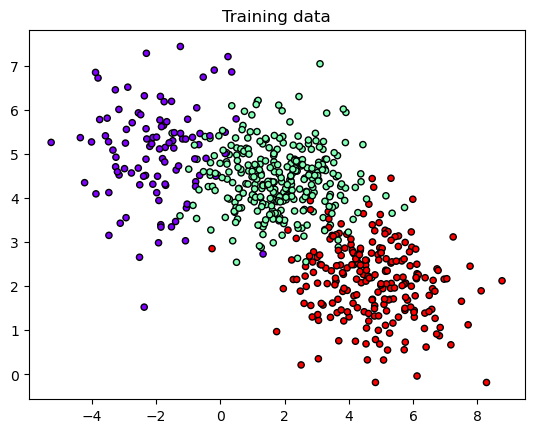

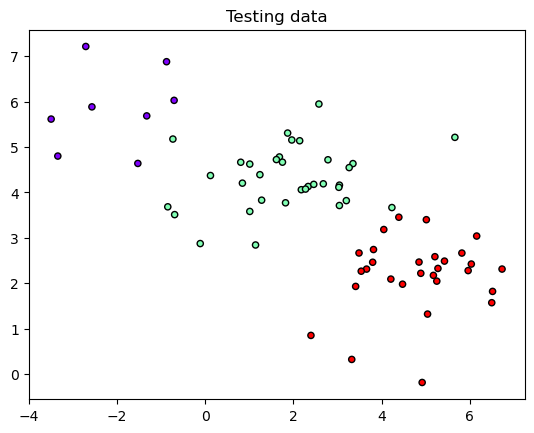

In [1]:
from classification import *

data_list = load_data("data_kla.txt")
data = np.array(data_list, dtype=np.float32)
X_all = data[:,:2]
y_all = data[:,2].astype(int)
X_train, y_train, X_test, y_test = split_data(X_all, y_all)

plot_data(X_train, y_train, "Training data")
plot_data(X_test, y_test, "Testing data")

Minimal distance Classifier
Accuracy: 94.37%


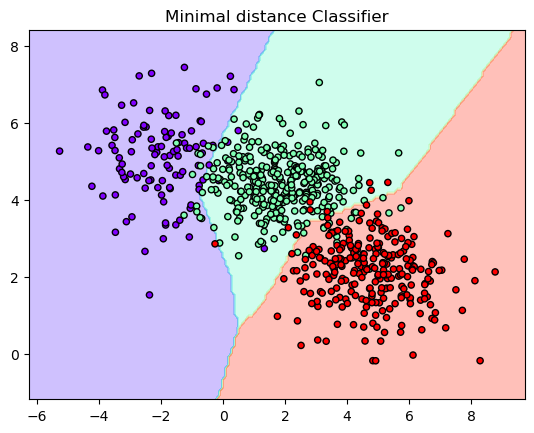

In [2]:
# Klasifikátor podle minimální vzdálenosti
print("Minimal distance Classifier")
mdc = MinDistanceClassifier(3)
mdc.train(X_train, y_train)
results = [mdc.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(mdc, X_all, y_all, "Minimal distance Classifier")

k-Nearest Neighbours Classifier
Accuracy (vote): 95.77%


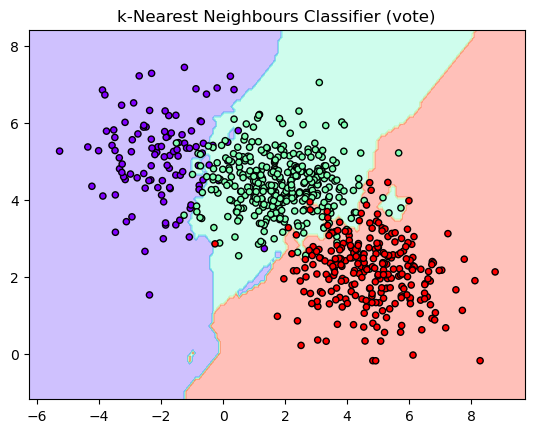

Accuracy (dist): 95.77%


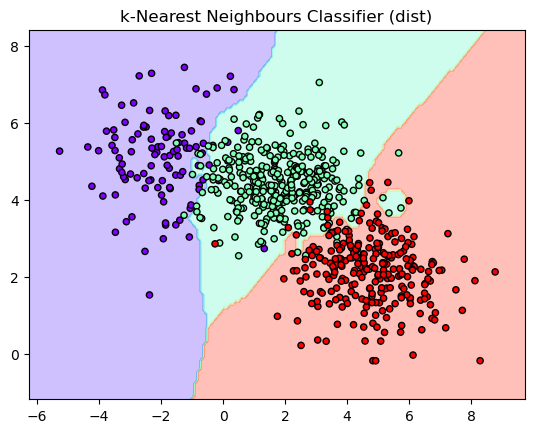

In [3]:
# Klasifikátor podle nejbližšího souseda
print("k-Nearest Neighbours Classifier")
knn = KNNClassifier(3)
knn.train(X_train, y_train)
results = [knn.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy (vote): {sum(results)/len(results) *100:.2f}%")
plot_boundaries(knn, X_all, y_all, "k-Nearest Neighbours Classifier (vote)")
knn.vote = False
results = [knn.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy (dist): {sum(results)/len(results) *100:.2f}%")
plot_boundaries(knn, X_all, y_all, "k-Nearest Neighbours Classifier (dist)")

Linear Discriminant Classifier
Metoda konst, třída 0, alfa 0.1: 1000 iterací
Metoda konst, třída 1, alfa 0.1: 1000 iterací
Metoda konst, třída 2, alfa 0.1: 1000 iterací
Accuracy: 91.55%


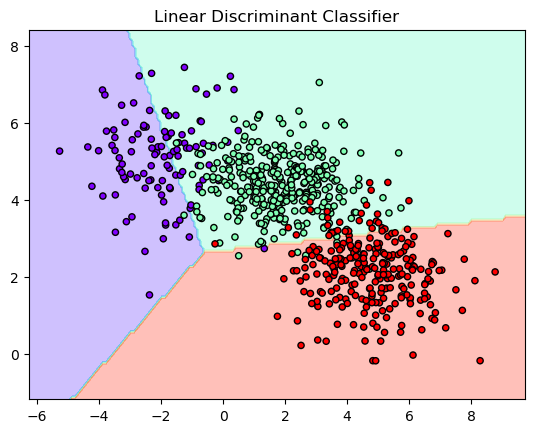

In [4]:
# Klasifikátor s lineárními diskriminačními funkcemi
print("Linear Discriminant Classifier")
lin = LinearDiscriminantClassifier(False, max_iters=1000)
lin.train(X_train, y_train)
results = [lin.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(lin, X_all, y_all, "Linear Discriminant Classifier")

Linear Discriminant Classifier (Rosenblatt)
Metoda rosenblatt, třída 0, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.1: 1000 iterací
Accuracy: 85.92%


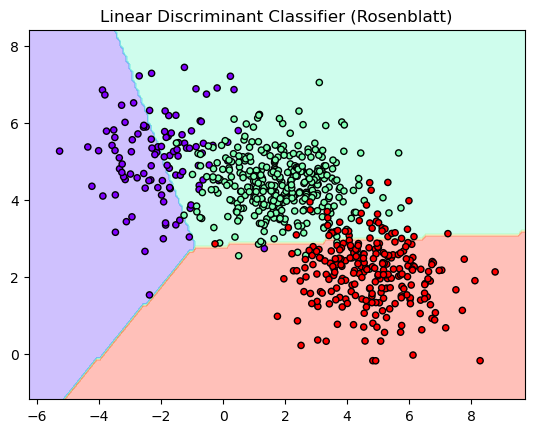

In [5]:
# Klasifikátor s lineárními diskriminačními funkcemi
print("Linear Discriminant Classifier (Rosenblatt)")
lin = LinearDiscriminantClassifier(True, max_iters=1000)
lin.train(X_train, y_train)
results = [lin.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(lin, X_all, y_all, "Linear Discriminant Classifier (Rosenblatt)")

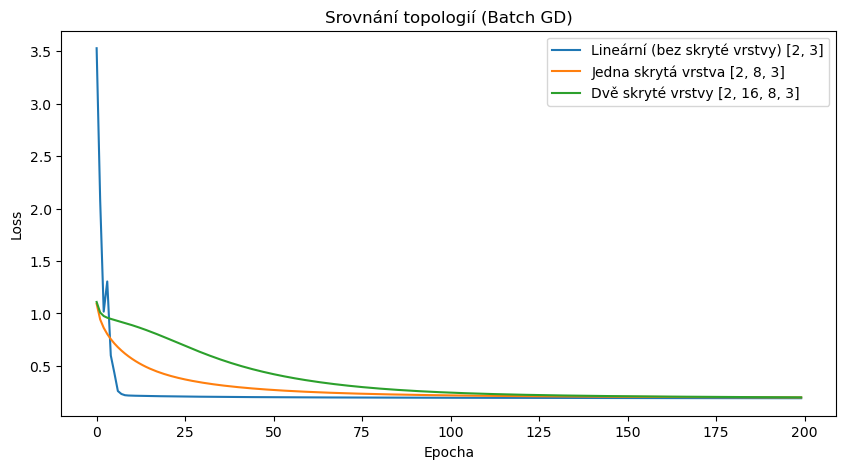

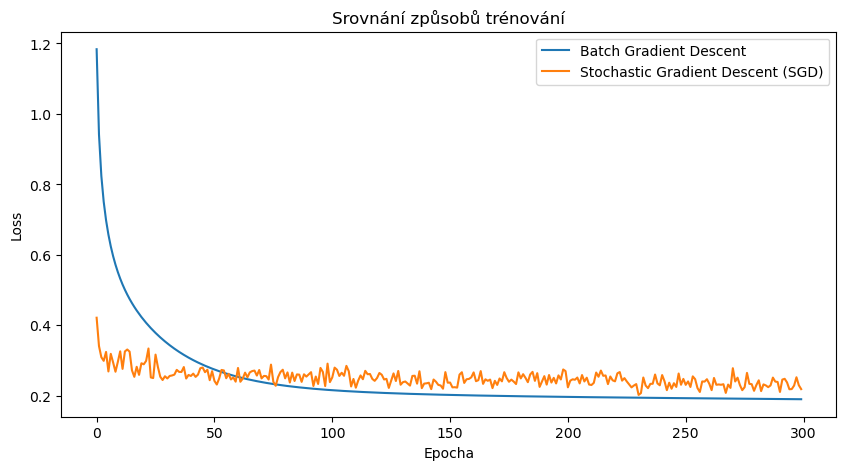

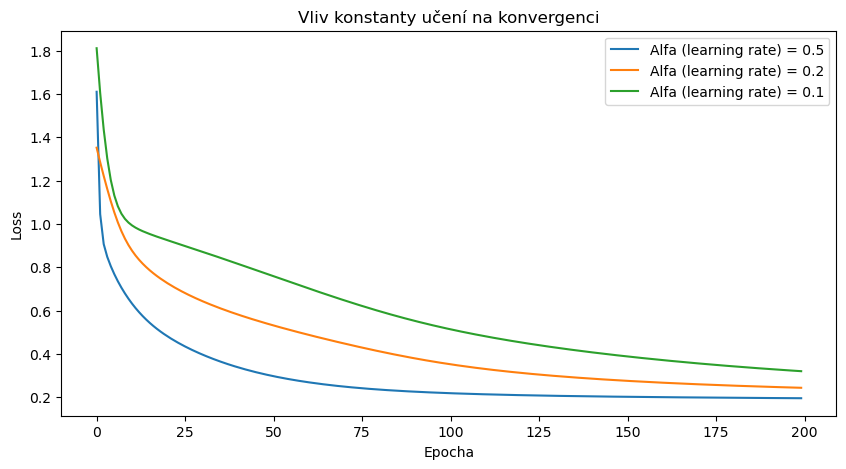

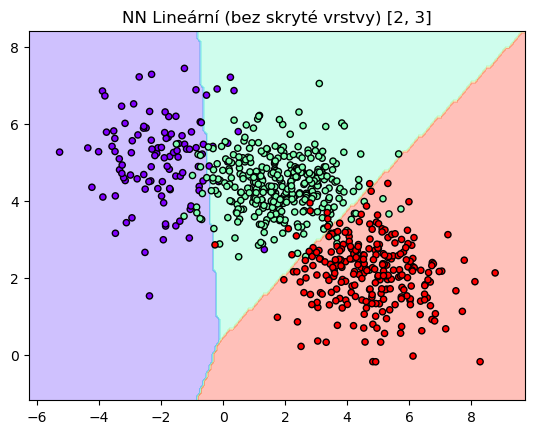

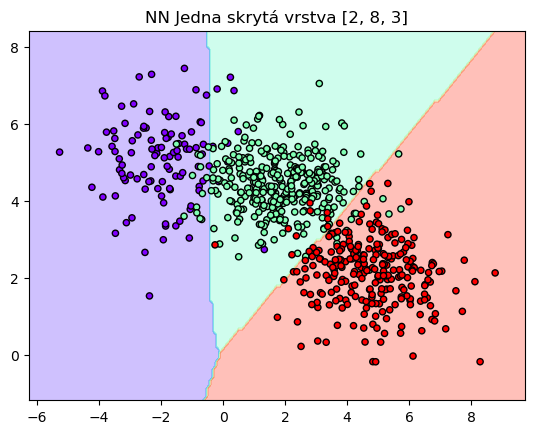

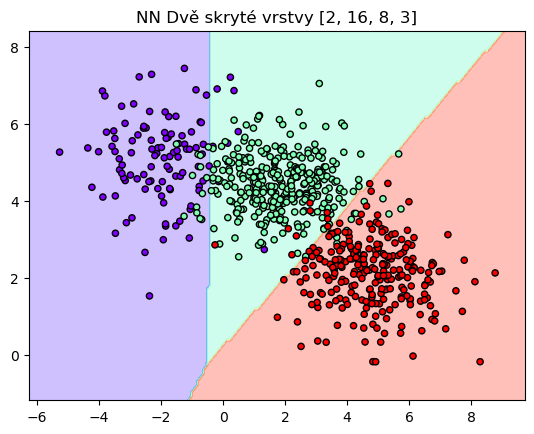

In [6]:
# NN
# Simulace ne-separabilních 2D dat (3 třídy)
# np.random.seed(42)
# X_train = np.vstack([
#     np.random.normal([-1, -1], 0.8, (100, 2)),
#     np.random.normal([2, 1], 0.8, (100, 2)),
#     np.random.normal([-1, 2], 0.8, (100, 2))
# ])
# y_train = np.array([0] * 100 + [1] * 100 + [2] * 100)

# --- EXPERIMENT 1: Vliv topologie ---
# Srovnáme lineární model [2, 3] vs. mělkou síť [2, 6, 3] vs. hlubší síť [2, 16, 8, 3]
topologies = {
    "Lineární (bez skryté vrstvy) [2, 3]": [2, 3],
    "Jedna skrytá vrstva [2, 8, 3]": [2, 8, 3],
    "Dvě skryté vrstvy [2, 16, 8, 3]": [2, 16, 8, 3]
}
base_lr = 0.5

plt.figure(figsize=(10, 5))
for name, topo in topologies.items():
    nn = SimpleNeuralNetwork(layer_sizes=topo, learning_rate=base_lr)
    loss = nn.train(X_train, y_train, epochs=200, method='batch')
    plt.plot(loss, label=name)
plt.title("Srovnání topologií (Batch GD)")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- EXPERIMENT 2: Způsob trénování (SGD vs Batch GD) ---
plt.figure(figsize=(10, 5))
nn_batch = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=base_lr)
loss_batch = nn_batch.train(X_train, y_train, epochs=300, method='batch')

nn_sgd = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=base_lr)
loss_sgd = nn_sgd.train(X_train, y_train, epochs=300, method='sgd')

plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent (SGD)")
plt.title("Srovnání způsobů trénování")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- EXPERIMENT 3: Volba konstanty učení (Learning Rate) ---
lrs = [0.5, 0.2, 0.1]
plt.figure(figsize=(10, 5))
for lr in lrs:
    nn = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=lr)
    loss = nn.train(X_train, y_train, epochs=200, method='batch')
    plt.plot(loss, label=f"Alfa (learning rate) = {lr}")
plt.title("Vliv konstanty učení na konvergenci")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

for name, topo in topologies.items():
    nn = SimpleNeuralNetwork(layer_sizes=topo, learning_rate=base_lr)
    loss = nn.train(X_train, y_train, epochs=200, method='batch')
    plot_boundaries(nn, X_all, y_all, f"NN {name}")